
### Imports, Data loading and Preprocessing ###

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.preprocessing import PowerTransformer

In [2]:
from indoor_plant_preprocessing import preprocessing

data, data_optimal = preprocessing()
display(data)
display(data_optimal)

,Plant_ID,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Optimal_Room_Temperature_C,Optimal_Humidity_%,Optimal_Soil_Moisture_%,Optimal_Light_Intensity_Lux,Light_Intensity,Pump_time
0,Sansevieria cylindrica,21.7,77.5,51.9,24,35,25,466,802,20.5
1,Aloe vera,22.6,68.9,28.2,24,35,25,850,970,19.1
2,Ficus lyrata,17.2,44.3,13.6,24,50,45,850,306,47.7
3,Monstera deliciosa,25.0,72.2,38.4,25,70,65,650,121,20.7
4,Ficus lyrata,23.2,51.6,37.9,24,50,45,850,520,46.5
...,...,...,...,...,...,...,...,...,...,...
995,Sansevieria cylindrica,32.4,58.0,31.7,24,35,25,466,981,37.0
996,Schefflera arboricola,24.3,39.4,32.9,23,50,45,633,957,9.1
997,Monstera deliciosa,26.4,52.4,58.5,25,70,65,650,861,13.4
998,Epipremnum aureum,18.7,60.1,24.8,24,60,55,400,786,44.2


,Plant_ID,Optimal_Room_Temperature_C,Optimal_Humidity_%,Optimal_Soil_Moisture_%,Optimal_Light_Intensity_Lux
0,Aglaonema commutatum,24,60,55,350
1,Aloe vera,24,35,25,850
2,Anthurium andraeanum,25,75,65,650
3,Begonia maculata,23,65,60,550
4,Calathea orbifolia,24,75,70,300
5,Chlorophytum comosum,22,55,50,450
6,Codiaeum variegatum,25,60,55,900
7,Dieffenbachia seguine,24,65,60,500
8,Dracaena trifasciata,23,40,30,700
9,Epipremnum aureum,24,60,55,400


### Outlier Analysis

The box plots show that most sensor features do not contain significant outliers, and the data distributions appear realistic and
consistent across plant species.

A few outliers are visible in the room temperature feature, but the values are still within a realistic environmental range for
indoor conditions. Therefore, these outliers were considered valid observations and were kept in the dataset.

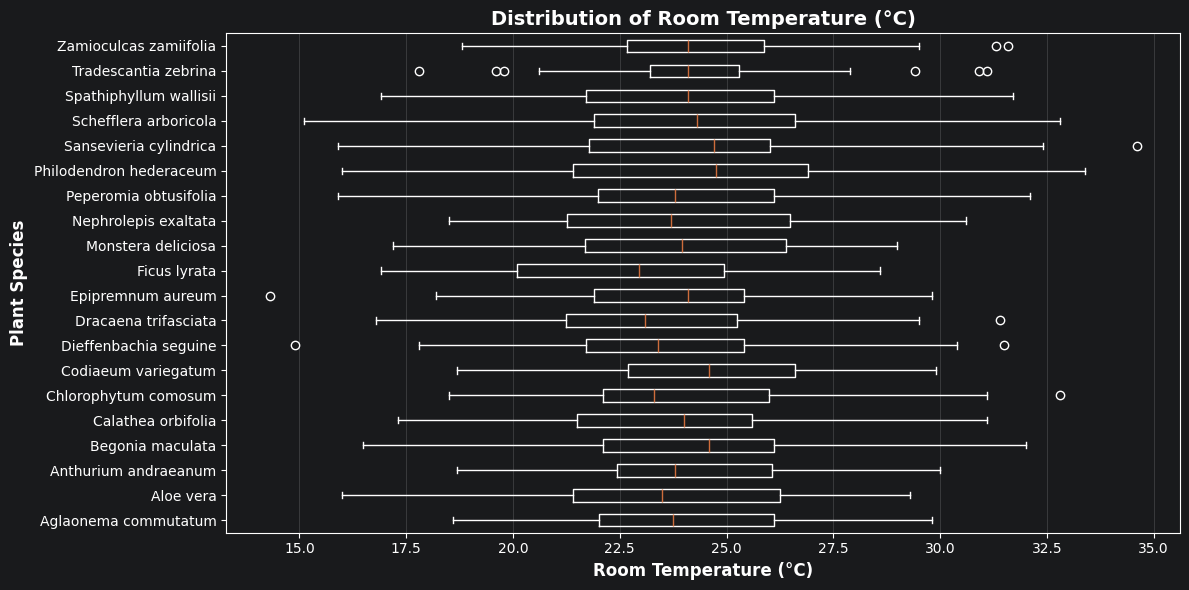

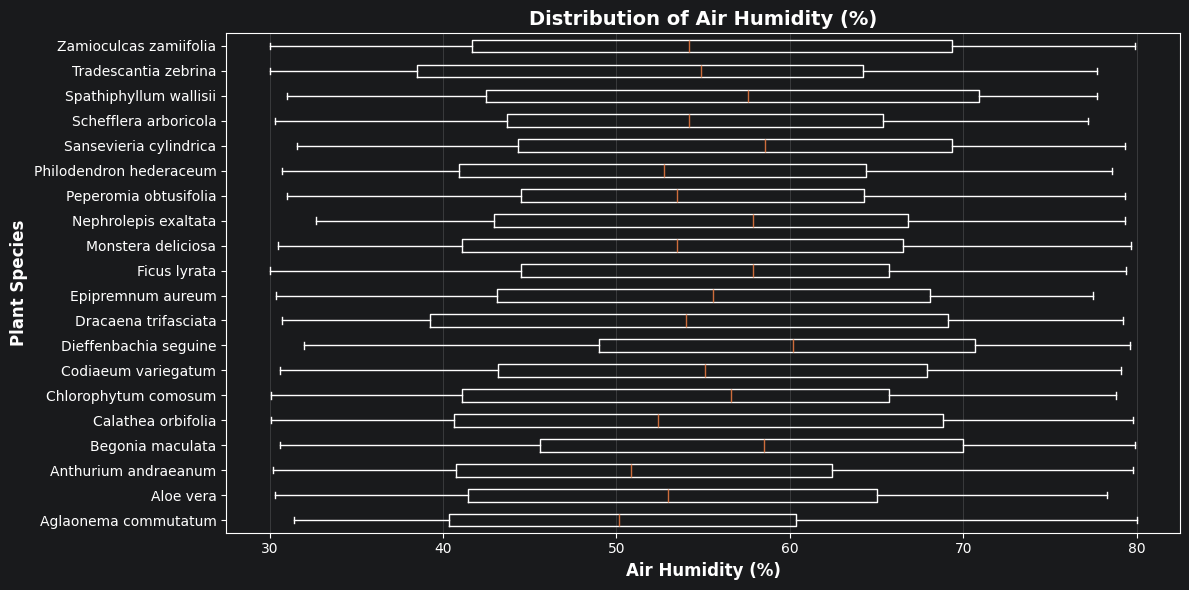

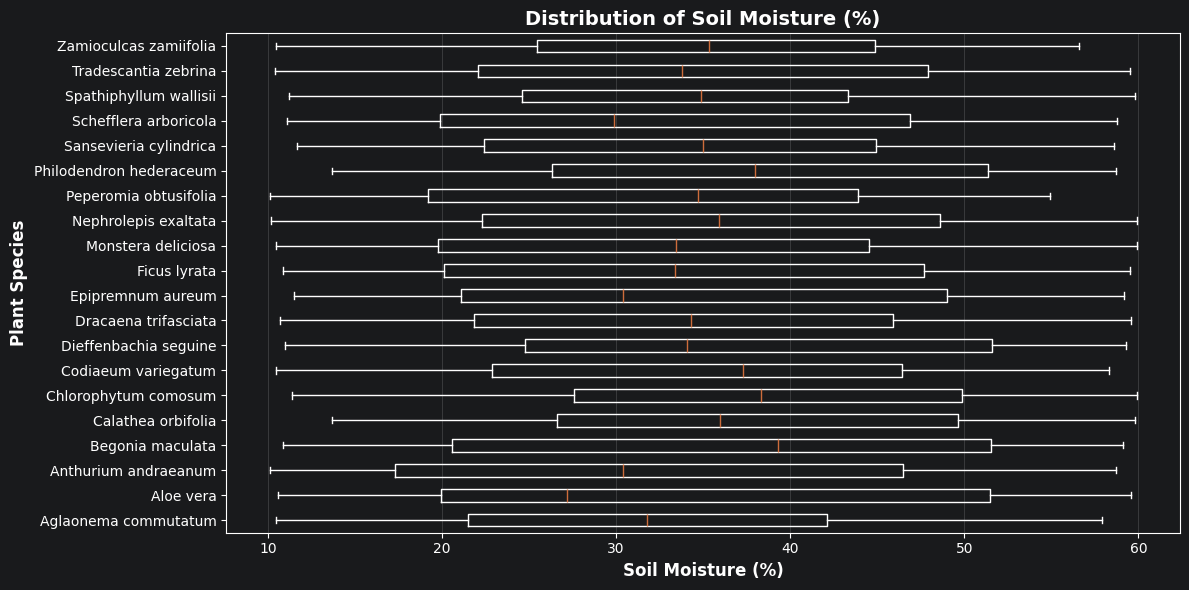

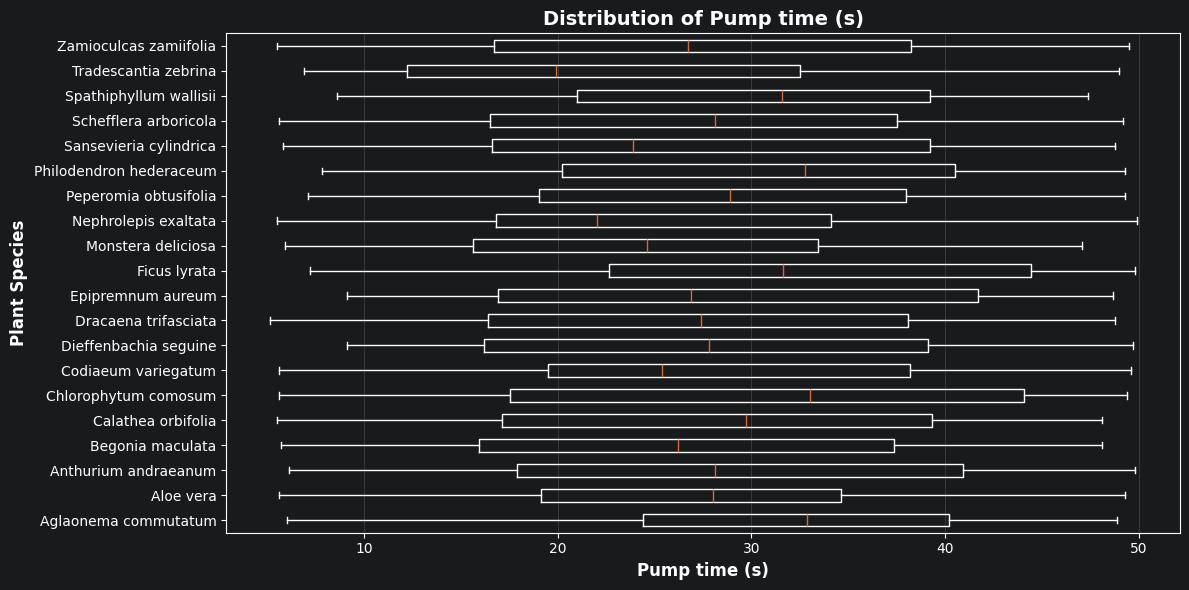

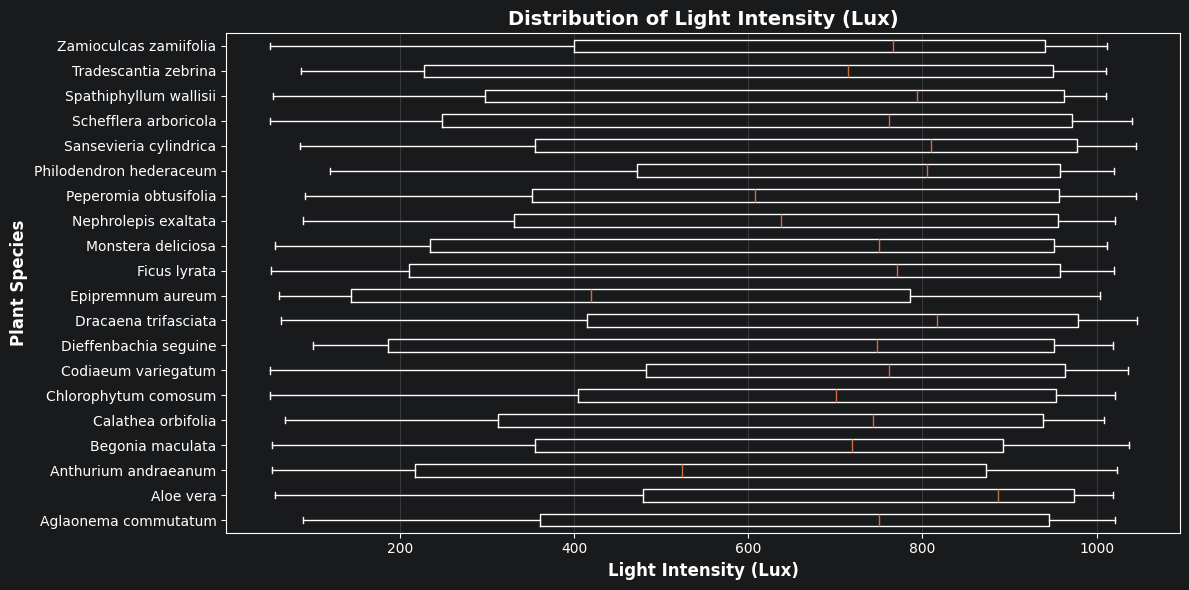

In [3]:
# Outliers
# Get unique plants
plants = sorted(data['Plant_ID'].unique())

# Define metrics
metrics = ['Room_Temperature_C', 'Humidity_%', 'Soil_Moisture_%', 'Pump_time', 'Light_Intensity']
metric_labels = ['Room Temperature (°C)', 'Air Humidity (%)', 'Soil Moisture (%)', 'Pump time (s)',
                 'Light Intensity (Lux)']

# Create boxplots for each metric
for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    fig, ax = plt.subplots(figsize=(12, 6))

    # Prepare data for each plant
    data_list = [data[data['Plant_ID'] == plant][metric].dropna().values for plant in plants]

    # Create horizontal boxplot
    ax.boxplot(data_list, tick_labels=plants, vert=False)
    ax.set_xlabel(label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Plant Species', fontsize=12, fontweight='bold')
    ax.set_title(f'Distribution of {label}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

## Initial Feature Engineering Approach

- Initially, we calculated the deficits and deviations derived from optimal values for each plant.

- Later, we realized this approach was flawed because the user does not know what plant they have, so we shouldn't expect that they know the optimal values for it.
- **Room Temperature** and **Light Intensity** were dropped because they were highly correlated with their deviations (according to the corr matrix)

In [4]:
# # Soil humidity deficit (optimal - current -> to get a positive value when it needs water)
# data['soil_deficit'] = (data['Optimal_Soil_Moisture_%'] - data['Soil_Moisture_%'])
#
# # Temperature deviation (current - optimal -> get a positive value when it's hotter than ideal)
# data['temp_deviation'] = (data['Room_Temperature_C'] - data['Optimal_Room_Temperature_C'])
#
# # Air humidity deficit (optimal - current -> positive means the air is too dry)
# data['air_hum_deficit'] = (data['Optimal_Humidity_%'] - data['Humidity_%'])
#
# # Light deviation (current - optimal -> get a positive value when it's more light than ideal)
# data['light_deviation'] = (data['Light_Intensity'] - data['Optimal_Light_Intensity_Lux'])
#
# # Approximate evapotranspiration (water loss due to heat, light, and dry air)
# data['et_approx'] = ((data['Room_Temperature_C'] * data['Light_Intensity']) / (data['Humidity_%'] + 1))

data = data.drop(columns=["Optimal_Humidity_%", "Optimal_Room_Temperature_C", "Optimal_Soil_Moisture_%",
                          "Optimal_Light_Intensity_Lux", "Room_Temperature_C", "Light_Intensity"])

data.head()

,Plant_ID,Humidity_%,Soil_Moisture_%,Pump_time,soil_deficit,temp_deviation,air_hum_deficit,light_deviation,et_approx
0,Sansevieria cylindrica,77.5,51.9,20.5,-26.9,-2.3,-42.5,336,221.699363
1,Aloe vera,68.9,28.2,19.1,-3.2,-1.4,-33.9,120,313.619456
2,Ficus lyrata,44.3,13.6,47.7,31.4,-6.8,5.7,-544,116.185430
3,Monstera deliciosa,72.2,38.4,20.7,26.6,0.0,-2.2,-529,41.325137
4,Ficus lyrata,51.6,37.9,46.5,7.1,-0.8,-1.6,-330,229.353612


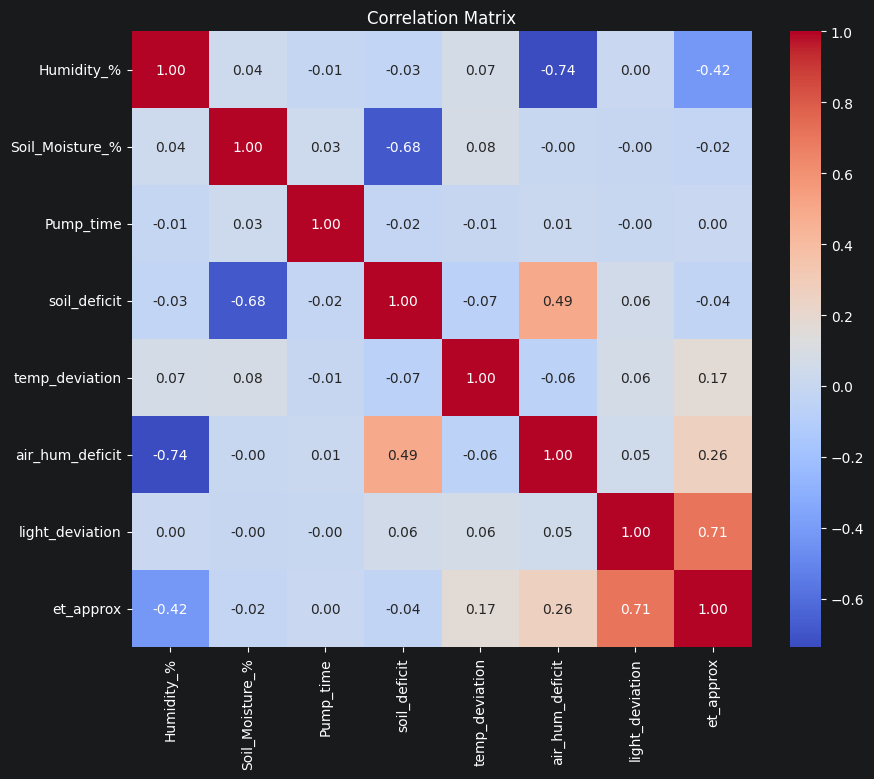

In [5]:
# Correlation matrix
numeric_data = data.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Train-Test Split ###

Here, we decided to use the `Plant_ID` column (representing the plant type/name) as the target variable, allowing the model to predict which plant it is based on the sensor readings and engineered features from the 20 plant types available in the system. Here we decided to set our Plant_ID column (with the plant's name) as a target column so the model predicts based on sensor + engineered features what plant is it exactly (from the 20 plants existing in the system).

In [6]:
# Data preparation
X = data.drop(columns=["Plant_ID"])
y = data["Plant_ID"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Random Forest Algorithm ###

In [7]:
# train a random forest classifier
n_features = X_train.shape[1]

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42, max_features=int(np.sqrt(n_features)))
rf_clf.fit(X_train, y_train);

In [8]:
# Evaluate the random forest on the train set
train_accuracy_rf = rf_clf.score(X_train, y_train)
print(f"Train set accuracy of random forest: {train_accuracy_rf:.2f}")
# Evaluate the random forest on the test set
accuracy_rf = rf_clf.score(X_test, y_test)
print(f"Test set accuracy of random forest: {accuracy_rf:.2f}")

Train set accuracy of random forest: 0.52
Test set accuracy of random forest: 0.23


In [9]:
# Feature importance from the random forest
feature_importances = rf_clf.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=True)
print(feature_importance_df)

           Feature  Importance
2        Pump_time    0.047958
7        et_approx    0.065024
1  Soil_Moisture_%    0.071538
4   temp_deviation    0.073850
0       Humidity_%    0.075291
3     soil_deficit    0.207000
5  air_hum_deficit    0.223883
6  light_deviation    0.235456


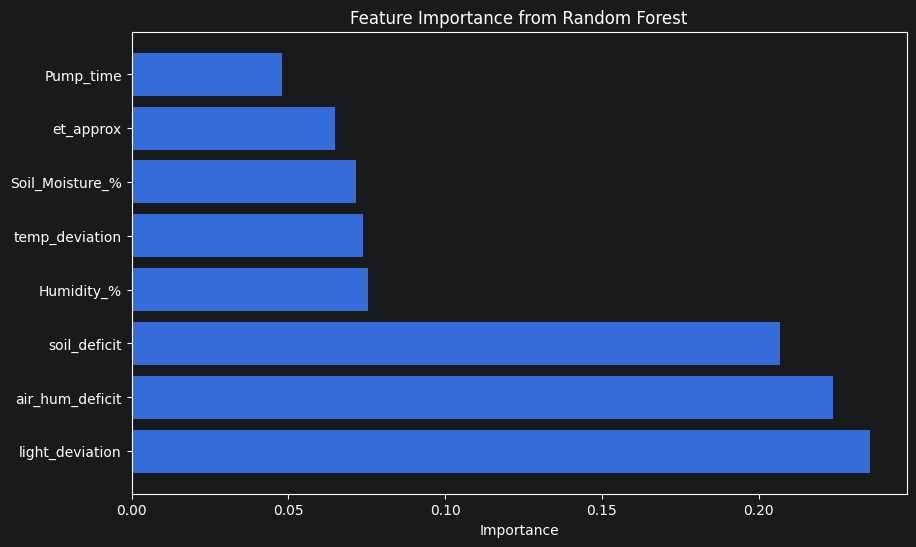

In [10]:
# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance from Random Forest")
plt.gca().invert_yaxis()
plt.show()

### kNN Classification Algorithm ###

In [11]:
# Columns to normalize
normalize_cols = ["light_deviation", "et_approx"]

# Normalize
pt = PowerTransformer(method='yeo-johnson')

X_train[normalize_cols] = pt.fit_transform(X_train[normalize_cols])
X_test[normalize_cols] = pt.transform(X_test[normalize_cols])

X_train.head()

,Humidity_%,Soil_Moisture_%,Pump_time,soil_deficit,temp_deviation,air_hum_deficit,light_deviation,et_approx
29,39.4,28.0,20.5,-3.0,1.8,-4.4,-0.763176,-1.389339
535,41.7,57.7,31.1,2.3,4.9,23.3,-0.866617,-0.170882
695,67.7,55.9,38.9,-10.9,2.2,-17.7,-1.640903,-1.713644
557,60.2,43.9,16.5,16.1,-0.7,4.8,0.311420,0.131985
836,64.1,42.9,40.9,12.1,4.9,-4.1,-2.016700,-1.149978


In [12]:
# Scaling
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled

,Humidity_%,Soil_Moisture_%,Pump_time,soil_deficit,temp_deviation,air_hum_deficit,light_deviation,et_approx
29,-1.072087,-0.473821,-0.606383,-0.936907,0.474880,-0.341253,-0.763176,-1.389339
535,-0.914030,1.590275,0.240978,-0.676087,1.450608,1.049005,-0.866617,-0.170882
695,0.872695,1.465178,0.864508,-1.325675,0.600780,-1.008778,-1.640903,-1.713644
557,0.357294,0.631200,-0.926142,0.003026,-0.311997,0.120493,0.311420,0.131985
836,0.625302,0.561702,1.024388,-0.193818,1.450608,-0.326196,-2.016700,-1.149978
...,...,...,...,...,...,...,...,...
106,-1.450048,1.652824,-1.525690,-2.442768,0.286030,-0.065209,0.767439,1.624326
270,-0.254316,1.666723,-0.110756,-1.468387,1.198807,-0.185665,0.580997,1.138983
860,-1.346968,0.547802,1.376122,-1.660311,0.884056,-0.140494,-0.624166,-0.909375
435,-1.188911,-0.307026,0.904478,0.421321,-0.123146,0.998815,-0.323267,0.022537


In [13]:
# Tuning hyperparameter
neighbors_range = range(3, 20)
distance_metrics = ['euclidean', 'manhattan', 'minkowski']

# Variables to store the best parameters and highest accuracy
best_accuracy = 0
best_params = {'n_neighbors': None, 'metric': None}

# Nested loop to iterate over the hyperparameters
for n_neighbors in neighbors_range:
    for metric in distance_metrics:
        # Initialize the KNN model with current hyperparameters
        knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric=metric)

        # Train the model
        knn.fit(X_train, y_train)

        # Make predictions on the test set
        predictions = knn.predict(X_test)

        # Calculate the accuracy
        accuracy = accuracy_score(y_test, predictions)

        # Update the best parameters if current accuracy is higher
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_params['n_neighbors'] = n_neighbors
            best_params['metric'] = metric

# Print the best set of parameters and the highest accuracy achieved
print(f"Best parameters: Number of Neighbors - {best_params['n_neighbors']}, Distance Metric - {best_params['metric']}")
print(f"Highest Accuracy: {best_accuracy * 100:.2f}%")

Best parameters: Number of Neighbors - 4, Distance Metric - euclidean
Highest Accuracy: 21.50%


## Conclusions
The Random Forest classification model did not achieve the best performance. We believe this is because many plants share very similar environmental characteristics and care requirements, making it difficult for the model to distinguish between them accurately based only on the available sensor and engineered features (low class separability).

This is why, in the next approach, we decided to group the plants into different environmental care types using clustering instead of trying to predict the exact plant species.